In [2]:
# COMPLETE_WORKFLOW_CELLS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare/load a dataset
DATA_PATH = "kc1.csv"
df = pd.read_csv(DATA_PATH, encoding='ISO-8859-1')

# Inspecting the dataset
print("Describe the dataset:", df.describe())
print("First five rows:", df.head())

Describe the dataset:                loc         v(g)        ev(g)        iv(g)            n  \
count  2109.000000  2109.000000  2109.000000  2109.000000  2109.000000   
mean     20.372262     2.838028     1.674443     2.546420    49.829445   
std      29.754442     3.900763     2.200659     3.375859    83.599874   
min       1.000000     1.000000     1.000000     1.000000     0.000000   
25%       3.000000     1.000000     1.000000     1.000000     4.000000   
50%       9.000000     1.000000     1.000000     1.000000    16.000000   
75%      24.000000     3.000000     1.000000     3.000000    58.000000   
max     288.000000    45.000000    26.000000    45.000000  1106.000000   

                 v            l            d            i              e  ...  \
count  2109.000000  2109.000000  2109.000000  2109.000000    2109.000000  ...   
mean    258.696719     0.319583     6.771242    21.240071    5242.386240  ...   
std     516.317605     0.317029     7.863646    21.500367   17444.98

defects
False    1783
True      326
Name: count, dtype: int64


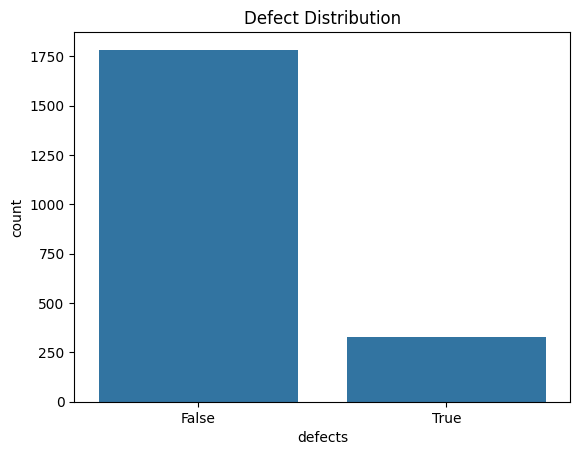

In [3]:
# Class distribution
print(df['defects'].value_counts())
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='defects', data=df)
plt.title("Defect Distribution")
plt.show()

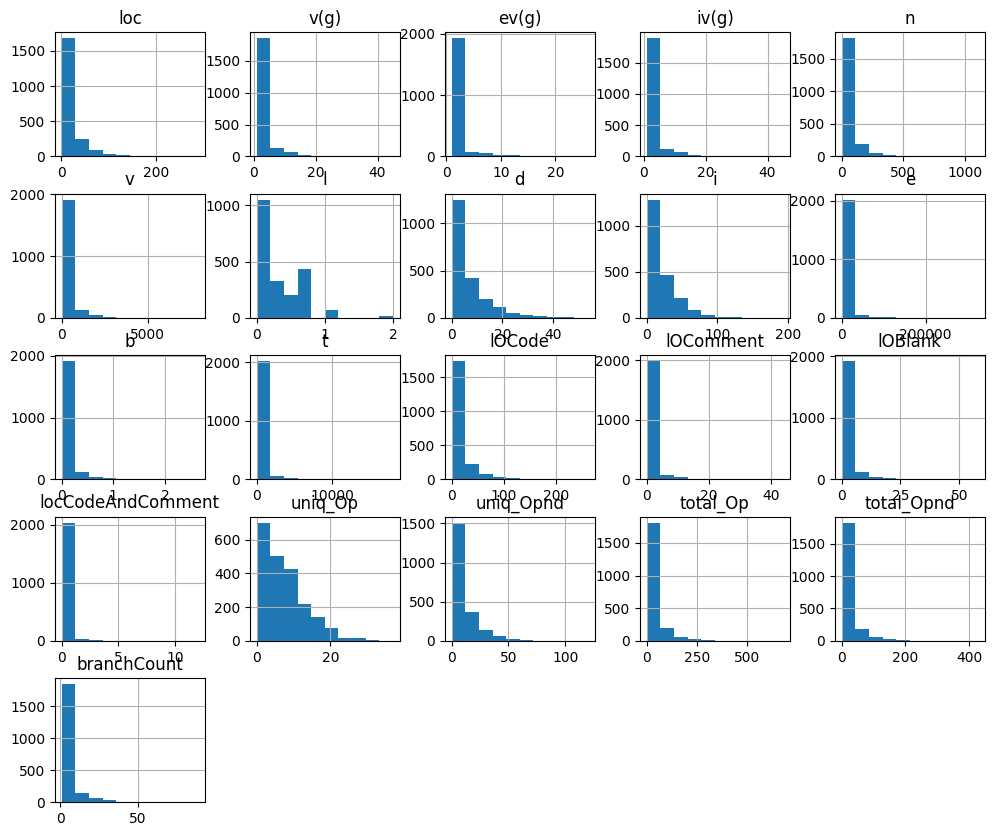

In [4]:
# Feature distributions
df.hist(figsize=(12,10))
plt.show()

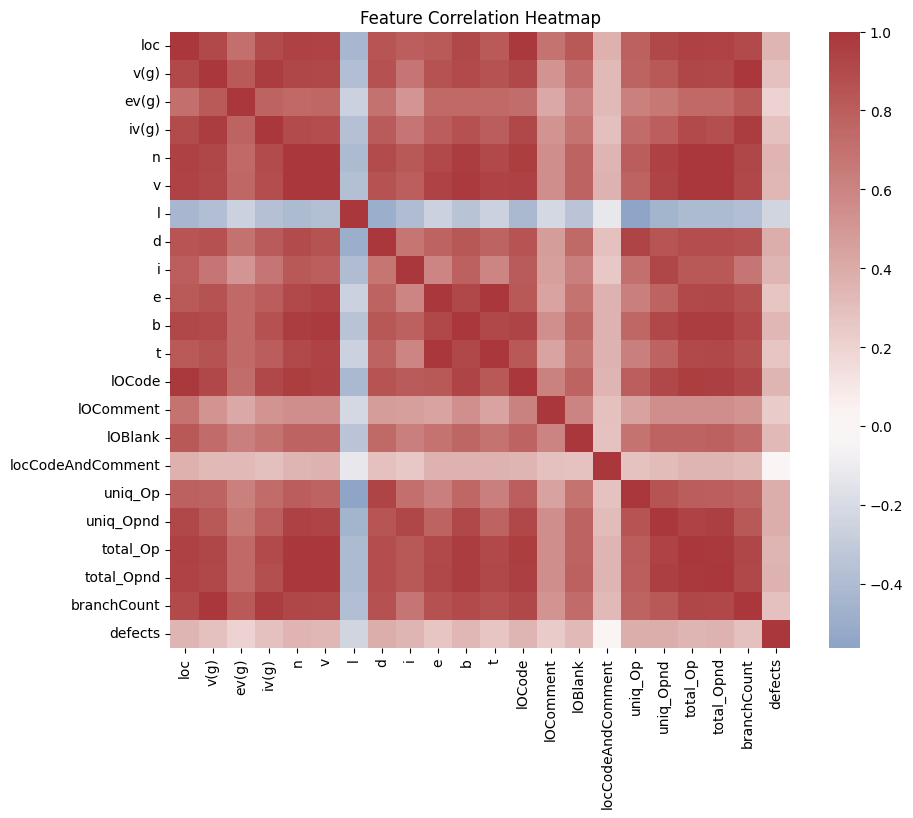

In [5]:
# Correlation heatmap
corr = df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap='vlag', center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

In [6]:
# DATA CLEANING, LABEL REFINEMENT, AND AUGMENTATIOM.
from sklearn.impute import KNNImputer
from sklearn.preprocessing import PowerTransformer

# Remove duplicate
df = df.drop_duplicates()

# Impute missing values using k-NN imputer (numeric features only)
numeric_cols = df.select_dtypes(include=[np.number]).columns
imputer = KNNImputer(n_neighbors=5)
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

In [7]:
# Normalize skewed metrics using log/Box-Cox transform
# (skip label column)
metrics = [col for col in numeric_cols if col != 'defects']
pt = PowerTransformer(method='yeo-johnson')  # handles zeros/negatives better than log
df[metrics] = pt.fit_transform(df[metrics])

In [8]:
# --- Label Refinement ---
# If label is binary defect proneness
if df['defects'].nunique() == 2:
    # Example: time-aware relabeling (if timestamp column exists)
    if 'timestamp' in df.columns:
        df = df.sort_values('timestamp')
        # Prevent leakage by shifting labels (demo: shift by 1)
        df['defect_refined'] = df['defect'].shift(-1).fillna(df['defects'])
    else:
        df['defect_refined'] = df['defects']
else:
    # If label is failure counts, apply smoothing/binning
    df['defect_refined'] = df['defects'].rolling(window=3, min_periods=1).mean()
    # Optional: bin into categories
    df['defect_bin'] = pd.qcut(df['defect_refined'], q=3, labels=['Low','Medium','High'])

In [9]:

# --- Augmentation ---
# 1.Gaussian noise injection for numeric features
aug_df = df.copy()
noise = np.random.normal(0, 0.01, size=aug_df[metrics].shape)  # small noise
aug_df[metrics] = aug_df[metrics] + noise

In [10]:
# 2. Dropout of noncritical metrics (simulate missing features)
drop_cols = np.random.choice(metrics, size=int(len(metrics)*0.1), replace=False)
aug_df[drop_cols] = 0

# 3. Synthetic telemetry generation (simple simulator)
# Example: generate random runtime signals correlated with defect label
aug_df['synthetic_runtime_signal'] = aug_df['defect_refined'] + np.random.normal(0, 0.5, size=len(aug_df))

# Combine original and augmented datasets
final_df = pd.concat([df, aug_df], ignore_index=True)

print("Final dataset shape after augmentation:", final_df.shape)
print(final_df.head())

Final dataset shape after augmentation: (2424, 24)
        loc      v(g)     ev(g)     iv(g)         n         v         l  \
0 -2.394461 -0.668366  0.624984 -0.570658 -1.998101 -2.074664  2.141111   
1 -2.445063 -1.123663 -0.538291 -1.074247 -2.074449 -2.119439  2.068101   
2  1.457066  1.513968 -0.538291  1.611863  1.171079  1.152091 -1.160117   
3  0.847417  1.289240  1.928823  1.411442  0.990314  0.999532 -0.732381   
4  0.227122  0.321448 -0.538291  0.475037  0.216147  0.183255 -0.259394   

          d         i         e  ...   lOBlank  locCodeAndComment   uniq_Op  \
0 -1.461256 -2.089462 -1.991945  ...  0.367139           3.247971 -1.945056   
1 -1.597357 -2.160807 -2.023329  ... -0.131113           3.245908 -2.017181   
2  1.381744  0.612347  1.260301  ...  1.187994          -0.307979  1.259391   
3  0.791662  1.005235  0.939396  ...  1.057870          -0.307979  0.985905   
4  0.228044  0.074027  0.212095  ...  0.367139          -0.307979  0.229866   

   uniq_Opnd  total_Op 

In [11]:
# Stage 4 — Feature Engineering and Representation

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_extraction.text import CountVectorizer

# Assume final_df is the cleaned + augmented dataset from Stage 3
df = final_df.copy()

# --- 1. Static Metrics Engineering ---
# Normalize metrics for consistent scale
metrics = [col for col in df.columns if col not in ['defects','defect_refined','defect_bin','synthetic_runtime_signal']]
scaler = StandardScaler()
df[metrics] = scaler.fit_transform(df[metrics])

In [12]:
# Interaction features (example: complexity × churn if available)
if 'cyclomatic' in df.columns and 'churn' in df.columns:
    df['complexity_churn_interaction'] = df['cyclomatic'] * df['churn']

# --- 2. Dimensionality Reduction (optional) ---
# Use PCA to capture latent structure in metrics
pca = PCA(n_components=5, random_state=42)
pca_features = pca.fit_transform(df[metrics])
for i in range(pca_features.shape[1]):
    df[f'pca_feature_{i+1}'] = pca_features[:, i]

In [13]:
# --- 3. Structural Code Embeddings (demo placeholder) ---
# If you have source code tokens, you can vectorize them.
# Here we simulate with a dummy 'code_tokens' column if available.
if 'code_tokens' in df.columns:
    vectorizer = CountVectorizer(max_features=500, ngram_range=(1,2))
    token_features = vectorizer.fit_transform(df['code_tokens'].astype(str))
    token_df = pd.DataFrame(token_features.toarray(), columns=vectorizer.get_feature_names_out())
    df = pd.concat([df.reset_index(drop=True), token_df.reset_index(drop=True)], axis=1)

In [14]:
# --- 4. Runtime / Telemetry Features ---
# Already added synthetic_runtime_signal in Stage 3
# Create statistical summaries (mean, std, rolling window)
df['runtime_mean'] = df['synthetic_runtime_signal'].rolling(window=5, min_periods=1).mean()
df['runtime_std'] = df['synthetic_runtime_signal'].rolling(window=5, min_periods=1).std().fillna(0)

# --- 5. Fusion-ready Dataset ---
# Final dataset now contains: normalized metrics, interaction features,
# PCA latent features, optional code embeddings, and runtime summaries.
print("Final engineered dataset shape:", df.shape)
print(df.head())

Final engineered dataset shape: (2424, 31)
        loc      v(g)     ev(g)     iv(g)         n         v         l  \
0 -2.394177 -0.667931  0.624961 -0.570480 -2.825741 -2.074813  2.140658   
1 -2.444778 -1.123131 -0.538214 -1.074076 -2.933713 -2.119592  2.067663   
2  1.457308  1.513937 -0.538214  1.612075  1.656156  1.152217 -1.159903   
3  0.847666  1.289257  1.928690  1.411652  1.400516  0.999646 -0.732254   
4  0.227377  0.321672 -0.538214  0.475232  0.305678  0.183298 -0.259362   

          d         i         e  ...  defects  defect_refined  \
0 -1.461262 -2.954945 -1.991583  ...    False           False   
1 -1.597349 -3.055843 -2.022963  ...     True            True   
2  1.381437  0.865989  1.260227  ...     True            True   
3  0.791417  1.421618  0.939365  ...     True            True   
4  0.227858  0.104690  0.212162  ...     True            True   

   synthetic_runtime_signal  pca_feature_1  pca_feature_2  pca_feature_3  \
0                       NaN      -5.115

In [15]:
# Hybrid Attention Model (PyTorch) + Training, Evaluation, Visualizations
# Assumes `df` from Stage 4 exists and contains:
# - numeric metric columns in `metrics` list
# - optional token/embedding matrix columns or PCA features for sequence input in `seq_cols`
# - label column 'defect_refined' (binary or continuous)
# - train/test split performed below

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, mean_squared_error, accuracy_score
from sklearn.calibration import calibration_curve
import random
import os

# -------------------------
# Reproducibility
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [16]:
# -------------------------
# Select features and labels (adjust names to your df)
metrics = [c for c in df.columns if c.startswith('pca_feature_') or c in ['complexity_churn_interaction','runtime_mean','runtime_std']]
# If you used token features or n-gram features, list them as seq_cols
seq_cols = [c for c in df.columns if c.startswith('token_')]  # replace with your token feature prefix
label_col = 'defect_refined'  # binary or continuous

# If seq_cols empty, use a sliding window of PCA features as a pseudo-sequence
if len(seq_cols) == 0:
    seq_cols = [f'pca_feature_{i+1}' for i in range(5)]  # ensure these exist

X_metrics = df[metrics].values.astype(np.float32)
X_seq = df[seq_cols].values.astype(np.float32)
y = df[label_col].values.astype(np.float32)

# Binary classification flag (adjust if regression)
is_classification = (df[label_col].nunique() == 2)

In [17]:
# Train/test split (time-aware split recommended; here simple stratified split for demo)
if is_classification:
    Xm_train, Xm_test, Xs_train, Xs_test, y_train, y_test = train_test_split(
        X_metrics, X_seq, y, test_size=0.2, stratify=y, random_state=seed)
else:
    Xm_train, Xm_test, Xs_train, Xs_test, y_train, y_test = train_test_split(
        X_metrics, X_seq, y, test_size=0.2, random_state=seed)

In [18]:
# -------------------------
# Dataset and DataLoader
class ReliabilityDataset(Dataset):
    def __init__(self, metrics_arr, seq_arr, labels):
        self.metrics = torch.from_numpy(metrics_arr)
        self.seq = torch.from_numpy(seq_arr)
        self.labels = torch.from_numpy(labels).unsqueeze(1).float()
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.metrics[idx], self.seq[idx], self.labels[idx]

batch_size = 32
train_ds = ReliabilityDataset(Xm_train, Xs_train, y_train)
test_ds = ReliabilityDataset(Xm_test, Xs_test, y_test)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

In [19]:
# -------------------------
# Model components
class CNNEncoder(nn.Module):
    def __init__(self, in_dim, out_dim=64):
        super().__init__()
        # Treat metrics as 1D sequence of length in_dim with 1 channel
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(64, out_dim)
        self.act = nn.ReLU()
    def forward(self, x):
        # x: (batch, features)
        x = x.unsqueeze(1)  # (batch, 1, features)
        x = self.act(self.conv1(x))
        x = self.act(self.conv2(x))
        x = self.pool(x).squeeze(-1)  # (batch, channels)
        x = self.fc(x)
        return x  # (batch, out_dim)

class SimpleTransformerEncoder(nn.Module):
    def __init__(self, seq_len, emb_dim=64, n_heads=4, ff_dim=128, n_layers=2, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(seq_len, emb_dim)  # project sequence vector to embedding
        self.pos_emb = nn.Parameter(torch.randn(1, emb_dim))  # simple global pos emb
        self.layers = nn.ModuleList([
            nn.ModuleDict({
                'mha': nn.MultiheadAttention(embed_dim=emb_dim, num_heads=n_heads, dropout=dropout, batch_first=True),
                'ff': nn.Sequential(nn.Linear(emb_dim, ff_dim), nn.ReLU(), nn.Linear(ff_dim, emb_dim)),
                'ln1': nn.LayerNorm(emb_dim),
                'ln2': nn.LayerNorm(emb_dim)
            }) for _ in range(n_layers)
        ])
    def forward(self, x):
        # x: (batch, seq_len) numeric vector representing tokens or PCA features
        # Project to (batch, 1, emb_dim) to use MultiheadAttention with batch_first
        emb = self.input_proj(x).unsqueeze(1) + self.pos_emb.unsqueeze(0)
        attn_weights_all = []
        out = emb
        for layer in self.layers:
            # Self-attention
            attn_out, attn_weights = layer['mha'](out, out, out, need_weights=True)
            out = layer['ln1'](out + attn_out)
            ff_out = layer['ff'](out)
            out = layer['ln2'](out + ff_out)
            attn_weights_all.append(attn_weights.detach().cpu().numpy())  # shape (batch, heads, tgt_len, src_len)
        # Return pooled representation and attention weights
        pooled = out.mean(dim=1)  # (batch, emb_dim)
        return pooled, attn_weights_all

class HybridAttentionModel(nn.Module):
    def __init__(self, metric_dim, seq_len, hidden_dim=128, num_heads=4):
        super().__init__()
        self.cnn_enc = CNNEncoder(in_dim=metric_dim, out_dim=hidden_dim//2)
        self.trans_enc = SimpleTransformerEncoder(seq_len=seq_len, emb_dim=hidden_dim//2, n_heads=num_heads)
        self.fusion_fc = nn.Sequential(
            nn.Linear(hidden_dim//2 + hidden_dim//2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.2)
        )
        # Heads
        self.class_head = nn.Sequential(nn.Linear(hidden_dim, 64), nn.ReLU(), nn.Linear(64, 1))
        self.reg_head = nn.Sequential(nn.Linear(hidden_dim, 64), nn.ReLU(), nn.Linear(64, 1))
    def forward(self, metrics, seq):
        m = self.cnn_enc(metrics)            # (batch, hidden/2)
        s, attn_weights = self.trans_enc(seq)  # (batch, hidden/2), list of attn arrays
        fused = torch.cat([m, s], dim=1)
        h = self.fusion_fc(fused)
        cls_logits = self.class_head(h)
        reg_out = self.reg_head(h)
        return cls_logits, reg_out, attn_weights

In [20]:
# Instantiate model
metric_dim = X_metrics.shape[1]
seq_len = X_seq.shape[1]
model = HybridAttentionModel(metric_dim, seq_len, hidden_dim=128, num_heads=4).to(device)

# -------------------------
# Losses, optimizer, scheduler
lr = 1e-3
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
if is_classification:
    criterion = nn.BCEWithLogitsLoss()
else:
    criterion = nn.MSELoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [21]:
# Check for NaN/inf in features and labels
import numpy as np
def check_array(name, arr):
    print(name, "shape:", arr.shape,
          "nan:", np.isnan(arr).sum(),
          "inf:", np.isinf(arr).sum(),
          "min:", np.nanmin(arr), "max:", np.nanmax(arr))

check_array("X_metrics", X_metrics)
check_array("X_seq", X_seq)
check_array("y", y)

# If any NaN/inf found, inspect rows
import pandas as pd
bad_rows = np.unique(np.concatenate([
    np.where(np.isnan(X_metrics).any(axis=1))[0],
    np.where(np.isinf(X_metrics).any(axis=1))[0],
    np.where(np.isnan(X_seq).any(axis=1))[0],
    np.where(np.isinf(X_seq).any(axis=1))[0],
    np.where(np.isnan(y))[0],
    np.where(np.isinf(y))[0]
]))
print("Rows with NaN/inf:", bad_rows[:20])


X_metrics shape: (2424, 7) nan: 1212 inf: 0 min: -7.7962093 max: 11.774829
X_seq shape: (2424, 5) nan: 0 inf: 0 min: -7.7962093 max: 11.774829
y shape: (2424,) nan: 0 inf: 0 min: 0.0 max: 1.0
Rows with NaN/inf: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]


In [22]:
# Inspect columns with NaNs and sample affected rows
import numpy as np
import pandas as pd

# assume df is your DataFrame used to build X_metrics/X_seq/y
numeric_cols = X_metrics.shape[1] and list(df[metrics].columns)  # metrics list from earlier
print("Numeric metric columns:", numeric_cols)

# Count NaNs per column
nan_counts = pd.DataFrame(X_metrics, columns=numeric_cols).isna().sum()
print("NaN counts per metric column:\n", nan_counts)

# Show first 30 rows of the original DataFrame to inspect problematic rows
print("Sample rows with NaNs (first 30):")
display(df.iloc[:30][numeric_cols + [label_col]].head(30))


Numeric metric columns: ['pca_feature_1', 'pca_feature_2', 'pca_feature_3', 'pca_feature_4', 'pca_feature_5', 'runtime_mean', 'runtime_std']
NaN counts per metric column:
 pca_feature_1       0
pca_feature_2       0
pca_feature_3       0
pca_feature_4       0
pca_feature_5       0
runtime_mean     1212
runtime_std         0
dtype: int64
Sample rows with NaNs (first 30):


,pca_feature_1,pca_feature_2,pca_feature_3,pca_feature_4,pca_feature_5,runtime_mean,runtime_std,defect_refined
0,-5.115494,-3.542623,3.795795,0.316592,-0.183452,NaN,0.0,False
1,-6.006853,-3.096606,3.689850,0.647348,-0.888771,NaN,0.0,True
2,5.498637,0.317679,-0.142818,1.025762,0.833716,NaN,0.0,True
3,4.843662,0.295007,-0.149963,-0.523775,1.466239,NaN,0.0,True
4,0.723188,0.138770,-0.741124,-0.149696,-0.301979,NaN,0.0,True
5,2.897632,1.326014,0.253953,0.984982,0.724164,NaN,0.0,True
6,3.987264,0.939061,-0.105067,0.528081,0.774649,NaN,0.0,True
7,5.675497,0.725645,-0.359169,0.468968,0.600873,NaN,0.0,True
8,3.868939,0.874129,-0.162116,0.408663,0.670901,NaN,0.0,True
9,4.191330,0.799028,-0.235875,0.369259,0.568831,NaN,0.0,True


In [23]:
# Cell 1: Inspect runtime columns
import numpy as np
import pandas as pd

print("Columns present:", [c for c in df.columns if 'runtime' in c or 'synthetic' in c])
print("Count NaNs in runtime_mean:", df['runtime_mean'].isna().sum())
print("Count NaNs in synthetic_runtime_signal:", df['synthetic_runtime_signal'].isna().sum())

# Show first 50 rows of the relevant columns to inspect pattern
display(df[['pca_feature_1','pca_feature_2','pca_feature_3','pca_feature_4','pca_feature_5','runtime_mean','runtime_std','synthetic_runtime_signal','defect_refined']].head(50))


Columns present: ['synthetic_runtime_signal', 'runtime_mean', 'runtime_std']
Count NaNs in runtime_mean: 1212
Count NaNs in synthetic_runtime_signal: 1212


,pca_feature_1,pca_feature_2,pca_feature_3,pca_feature_4,pca_feature_5,runtime_mean,runtime_std,synthetic_runtime_signal,defect_refined
0,-5.115494,-3.542623,3.795795,0.316592,-0.183452,NaN,0.0,NaN,False
1,-6.006853,-3.096606,3.689850,0.647348,-0.888771,NaN,0.0,NaN,True
2,5.498637,0.317679,-0.142818,1.025762,0.833716,NaN,0.0,NaN,True
3,4.843662,0.295007,-0.149963,-0.523775,1.466239,NaN,0.0,NaN,True
4,0.723188,0.138770,-0.741124,-0.149696,-0.301979,NaN,0.0,NaN,True
5,2.897632,1.326014,0.253953,0.984982,0.724164,NaN,0.0,NaN,True
6,3.987264,0.939061,-0.105067,0.528081,0.774649,NaN,0.0,NaN,True
7,5.675497,0.725645,-0.359169,0.468968,0.600873,NaN,0.0,NaN,True
8,3.868939,0.874129,-0.162116,0.408663,0.670901,NaN,0.0,NaN,True
9,4.191330,0.799028,-0.235875,0.369259,0.568831,NaN,0.0,NaN,True


In [24]:
# Cell 2: Recompute runtime_mean if synthetic_runtime_signal exists, else impute median
if 'synthetic_runtime_signal' in df.columns:
    # Recompute rolling mean with min_periods=1 to avoid NaNs at start
    df['runtime_mean_recomputed'] = df['synthetic_runtime_signal'].rolling(window=5, min_periods=1).mean()
    # If original runtime_std was computed with rolling and had NaNs, recompute it too
    df['runtime_std_recomputed'] = df['synthetic_runtime_signal'].rolling(window=5, min_periods=1).std().fillna(0)
    # Replace runtime_mean/runtime_std with recomputed where NaN or always (safer to use recomputed)
    df['runtime_mean'] = df['runtime_mean_recomputed']
    df['runtime_std'] = df['runtime_std_recomputed']
    df.drop(columns=['runtime_mean_recomputed','runtime_std_recomputed'], inplace=True)
    print("Recomputed runtime_mean and runtime_std from synthetic_runtime_signal.")
else:
    print("No synthetic_runtime_signal column found; will impute runtime_mean with median.")

# Impute remaining NaNs in runtime_mean with median
median_runtime_mean = df['runtime_mean'].median()
df['runtime_mean'] = df['runtime_mean'].fillna(median_runtime_mean)
print("NaNs after imputation (runtime_mean):", df['runtime_mean'].isna().sum())
print("runtime_mean median used for imputation:", median_runtime_mean)


Recomputed runtime_mean and runtime_std from synthetic_runtime_signal.
NaNs after imputation (runtime_mean): 0
runtime_mean median used for imputation: 0.09455525770254328


In [25]:
# Cell 3: Re-check NaN/inf counts for metric columns
numeric_cols = ['pca_feature_1','pca_feature_2','pca_feature_3','pca_feature_4','pca_feature_5','runtime_mean','runtime_std']
nan_counts = df[numeric_cols].isna().sum()
inf_counts = np.isinf(df[numeric_cols]).sum()
print("NaN counts per metric column:\n", nan_counts)
print("Inf counts per metric column:\n", inf_counts)

# Show sample rows again to confirm
display(df[numeric_cols + [label_col]].head(30))


NaN counts per metric column:
 pca_feature_1    0
pca_feature_2    0
pca_feature_3    0
pca_feature_4    0
pca_feature_5    0
runtime_mean     0
runtime_std      0
dtype: int64
Inf counts per metric column:
 pca_feature_1    0
pca_feature_2    0
pca_feature_3    0
pca_feature_4    0
pca_feature_5    0
runtime_mean     0
runtime_std      0
dtype: int64


,pca_feature_1,pca_feature_2,pca_feature_3,pca_feature_4,pca_feature_5,runtime_mean,runtime_std,defect_refined
0,-5.115494,-3.542623,3.795795,0.316592,-0.183452,0.094555,0.0,False
1,-6.006853,-3.096606,3.689850,0.647348,-0.888771,0.094555,0.0,True
2,5.498637,0.317679,-0.142818,1.025762,0.833716,0.094555,0.0,True
3,4.843662,0.295007,-0.149963,-0.523775,1.466239,0.094555,0.0,True
4,0.723188,0.138770,-0.741124,-0.149696,-0.301979,0.094555,0.0,True
5,2.897632,1.326014,0.253953,0.984982,0.724164,0.094555,0.0,True
6,3.987264,0.939061,-0.105067,0.528081,0.774649,0.094555,0.0,True
7,5.675497,0.725645,-0.359169,0.468968,0.600873,0.094555,0.0,True
8,3.868939,0.874129,-0.162116,0.408663,0.670901,0.094555,0.0,True
9,4.191330,0.799028,-0.235875,0.369259,0.568831,0.094555,0.0,True


In [26]:
# Cell 4: Final safe cleaning and recreate arrays used by model
import numpy as np

def safe_clean(arr, name):
    arr = np.array(arr, dtype=np.float32)
    # Replace pos/neg inf with finite extremes
    finite_mask = np.isfinite(arr)
    if not finite_mask.all():
        finite_vals = arr[np.isfinite(arr)]
        if finite_vals.size == 0:
            raise ValueError(f"No finite values in {name} to infer replacements.")
        max_f = np.nanmax(finite_vals)
        min_f = np.nanmin(finite_vals)
        arr = np.where(np.isposinf(arr), max_f, arr)
        arr = np.where(np.isneginf(arr), min_f, arr)
        # replace NaN with column medians
        col_medians = np.nanmedian(arr, axis=0)
        inds = np.where(np.isnan(arr))
        for r, c in zip(*inds):
            arr[r, c] = col_medians[c]
    # final check
    print(f"{name} final check -> shape: {arr.shape}, nan: {np.isnan(arr).sum()}, inf: {np.isinf(arr).sum()}, min: {arr.min()}, max: {arr.max()}")
    return arr

# Recreate arrays from df (use the same metrics and seq_cols as before)
metrics = ['pca_feature_1','pca_feature_2','pca_feature_3','pca_feature_4','pca_feature_5','runtime_mean','runtime_std']
# seq_cols defined earlier; if not, fallback to PCA features
try:
    seq_cols
except NameError:
    seq_cols = [f'pca_feature_{i+1}' for i in range(5)]

X_metrics = df[metrics].values.astype(np.float32)
X_seq = df[seq_cols].values.astype(np.float32)
y = df[label_col].values.astype(np.float32)

# Clean arrays
X_metrics = safe_clean(X_metrics, "X_metrics")
X_seq = safe_clean(X_seq, "X_seq")
print("y final check -> nan:", np.isnan(y).sum(), "inf:", np.isinf(y).sum(), "min:", np.nanmin(y), "max:", np.nanmax(y))


X_metrics final check -> shape: (2424, 7), nan: 0, inf: 0, min: -7.796209335327148, max: 11.774828910827637
X_seq final check -> shape: (2424, 5), nan: 0, inf: 0, min: -7.796209335327148, max: 11.774828910827637
y final check -> nan: 0 inf: 0 min: 0.0 max: 1.0


In [27]:
# Cell 5: Recreate Dataset/DataLoader and run a single debug training step
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

class ReliabilityDataset(Dataset):
    def __init__(self, metrics_arr, seq_arr, labels):
        self.metrics = torch.from_numpy(metrics_arr).float()
        self.seq = torch.from_numpy(seq_arr).float()
        self.labels = torch.from_numpy(labels).float().reshape(-1,1)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return self.metrics[idx], self.seq[idx], self.labels[idx]

# Train/test split (use stratify for classification)
is_classification = (df[label_col].nunique() == 2)
if is_classification:
    Xm_train, Xm_test, Xs_train, Xs_test, y_train, y_test = train_test_split(
        X_metrics, X_seq, y, test_size=0.2, stratify=y, random_state=42)
else:
    Xm_train, Xm_test, Xs_train, Xs_test, y_train, y_test = train_test_split(
        X_metrics, X_seq, y, test_size=0.2, random_state=42)

train_ds = ReliabilityDataset(Xm_train, Xs_train, y_train)
test_ds = ReliabilityDataset(Xm_test, Xs_test, y_test)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, drop_last=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

print("Train size:", len(train_ds), "Test size:", len(test_ds))

# One debug training step (assumes model, optimizer, criterion, device exist)
model.train()
optimizer.zero_grad()

# get one batch
xm, xs, yb = next(iter(train_loader))
xm = xm.to(device).float()
xs = xs.to(device).float()
yb = yb.to(device).float()

# quick checks
print("Batch shapes -> xm:", xm.shape, "xs:", xs.shape, "yb:", yb.shape)
print("Batch stats -> xm mean/std:", xm.mean().item(), xm.std().item(), "yb min/max:", yb.min().item(), yb.max().item())

# forward
cls_logits, reg_out, _ = model(xm, xs)
preds = cls_logits if is_classification else reg_out

# compute loss
loss = criterion(preds, yb)
print("Initial batch loss:", loss.item())

# backward with gradient clipping
loss.backward()
torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
optimizer.step()
print("One debug step completed successfully.")


Train size: 1939 Test size: 485
Batch shapes -> xm: torch.Size([32, 7]) xs: torch.Size([32, 5]) yb: torch.Size([32, 1])
Batch stats -> xm mean/std: -0.0365779809653759 1.6363365650177002 yb min/max: 0.0 1.0
Initial batch loss: 0.6632721424102783
One debug step completed successfully.


In [28]:
# Cell A: Inspect first batch values and shapes before forward pass
xm, xs, yb = next(iter(train_loader))
print("xm dtype/device:", xm.dtype, xm.device if hasattr(xm,'device') else 'cpu')
print("xs dtype/device:", xs.dtype, xs.device if hasattr(xs,'device') else 'cpu')
print("yb dtype/device:", yb.dtype, yb.device if hasattr(yb,'device') else 'cpu')

# Basic stats
import numpy as np
def stats(name, arr):
    a = arr.numpy() if isinstance(arr, torch.Tensor) else np.array(arr)
    print(f"{name} shape:{a.shape} nan:{np.isnan(a).sum()} inf:{np.isinf(a).sum()} min:{np.nanmin(a):.6g} max:{np.nanmax(a):.6g} mean:{np.nanmean(a):.6g} std:{np.nanstd(a):.6g}")

stats("xm", xm)
stats("xs", xs)
stats("yb", yb)

# Move to device and check again
xm_d = xm.to(device).float()
xs_d = xs.to(device).float()
yb_d = yb.to(device).float()
print("Moved to device:", device)
stats("xm_d", xm_d.cpu())
stats("xs_d", xs_d.cpu())
stats("yb_d", yb_d.cpu())


xm dtype/device: torch.float32 cpu
xs dtype/device: torch.float32 cpu
yb dtype/device: torch.float32 cpu
xm shape:(32, 7) nan:0 inf:0 min:-6.94371 max:5.24392 mean:0.010294 std:1.43444
xs shape:(32, 5) nan:0 inf:0 min:-6.94371 max:5.24392 mean:-0.0819348 std:1.67391
yb shape:(32, 1) nan:0 inf:0 min:0 max:1 mean:0.15625 std:0.363092
Moved to device: cpu
xm_d shape:(32, 7) nan:0 inf:0 min:-6.94371 max:5.24392 mean:0.010294 std:1.43444
xs_d shape:(32, 5) nan:0 inf:0 min:-6.94371 max:5.24392 mean:-0.0819348 std:1.67391
yb_d shape:(32, 1) nan:0 inf:0 min:0 max:1 mean:0.15625 std:0.363092


In [29]:
# Cell B: Run forward in eval mode to inspect raw logits and loss before backward
model.eval()
with torch.no_grad():
    cls_logits, reg_out, attn = model(xm_d, xs_d)

# If classification, inspect logits and sigmoid outputs
if is_classification:
    logits = cls_logits.detach().cpu().numpy().flatten()
    probs = torch.sigmoid(cls_logits).detach().cpu().numpy().flatten()
    import numpy as np
    print("Logits stats -> min/max/mean/std:", np.min(logits), np.max(logits), np.mean(logits), np.std(logits))
    print("Probs stats -> min/max/mean/std:", np.min(probs), np.max(probs), np.mean(probs), np.std(probs))
else:
    preds = reg_out.detach().cpu().numpy().flatten()
    print("Regression preds stats -> min/max/mean/std:", preds.min(), preds.max(), preds.mean(), preds.std())

# Compute loss value without backward to see if NaN arises here
if is_classification:
    # BCEWithLogitsLoss expects logits and labels in [0,1]
    loss_val = criterion(cls_logits, yb_d)
else:
    loss_val = criterion(reg_out, yb_d)
print("Loss (no backward):", loss_val.item())


Logits stats -> min/max/mean/std: -0.32645237 -0.20324695 -0.242445 0.030279545
Probs stats -> min/max/mean/std: 0.4191041 0.44936243 0.43969816 0.0074417754
Loss (no backward): 0.6177498698234558


In [30]:
# Cell C: Clean labels and clamp extreme inputs (run only if previous cell showed extreme values or NaN)
# 1) Ensure labels are 0/1 floats for BCE
if is_classification:
    # clamp labels to [0,1] and ensure float32
    yb_d = torch.clamp(yb_d, 0.0, 1.0).float()
    print("Labels clamped to [0,1], unique:", torch.unique(yb_d))

# 2) Replace any NaN/inf in xm_d/xs_d with column medians
def replace_nan_inf(tensor, name):
    arr = tensor.cpu().numpy()
    # replace inf with finite extremes
    finite = arr[np.isfinite(arr)]
    if finite.size == 0:
        raise ValueError(f"No finite values in {name}")
    max_f, min_f = finite.max(), finite.min()
    arr = np.where(np.isposinf(arr), max_f, arr)
    arr = np.where(np.isneginf(arr), min_f, arr)
    # replace NaN with column medians
    col_medians = np.nanmedian(arr, axis=0)
    inds = np.where(np.isnan(arr))
    for r, c in zip(*inds):
        arr[r, c] = col_medians[c]
    return torch.from_numpy(arr).to(device).float()

if torch.isnan(xm_d).any() or torch.isinf(xm_d).any():
    xm_d = replace_nan_inf(xm_d, "xm_d")
    print("Replaced NaN/inf in xm_d")
if torch.isnan(xs_d).any() or torch.isinf(xs_d).any():
    xs_d = replace_nan_inf(xs_d, "xs_d")
    print("Replaced NaN/inf in xs_d")

# Recompute logits and loss after cleaning
model.eval()
with torch.no_grad():
    cls_logits2, reg_out2, _ = model(xm_d, xs_d)
if is_classification:
    print("Post-clean logits stats:", cls_logits2.min().item(), cls_logits2.max().item(), cls_logits2.mean().item(), cls_logits2.std().item())
    print("Post-clean loss:", criterion(cls_logits2, yb_d).item())
else:
    print("Post-clean reg preds stats:", reg_out2.min().item(), reg_out2.max().item(), reg_out2.mean().item(), reg_out2.std().item())
    print("Post-clean loss:", criterion(reg_out2, yb_d).item())


Labels clamped to [0,1], unique: tensor([0., 1.])
Post-clean logits stats: -0.326452374458313 -0.20324695110321045 -0.2424449920654297 0.030764048919081688
Post-clean loss: 0.6177498698234558


In [31]:
# Cell D: Initialize weights and reduce LR for stability
def init_weights(m):
    if isinstance(m, (torch.nn.Linear, torch.nn.Conv1d)):
        torch.nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            torch.nn.init.zeros_(m.bias)

model.apply(init_weights)
print("Applied Xavier init to model.")

# Reduce LR drastically for debugging
for g in optimizer.param_groups:
    g['lr'] = 1e-5
print("Set optimizer LR to", optimizer.param_groups[0]['lr'])


Applied Xavier init to model.
Set optimizer LR to 1e-05


In [32]:
# Cell E: Single training step with anomaly detection and gradient clipping
model.train()
optimizer.zero_grad()

# Use cleaned tensors xm_d, xs_d, yb_d from above
try:
    with torch.autograd.detect_anomaly():
        cls_logits, reg_out, _ = model(xm_d, xs_d)
        preds = cls_logits if is_classification else reg_out
        loss = criterion(preds, yb_d)
        print("Computed loss before backward:", loss.item())
        if torch.isnan(loss) or torch.isinf(loss):
            raise ValueError("Loss is NaN/Inf before backward.")
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        print("Guarded training step completed successfully.")
except Exception as e:
    print("Exception during guarded training step:", repr(e))
    # Print gradients stats for debugging
    grads = [p.grad.detach().cpu().abs().mean().item() if p.grad is not None else 0.0 for p in model.parameters()]
    print("Gradients mean (sample):", grads[:10])
    raise


C:\Users\TUNTU\AppData\Local\Temp\ipykernel_20252\965058589.py:7: UserWarning: Anomaly Detection has been enabled. This mode will increase the runtime and should only be enabled for debugging.
  with torch.autograd.detect_anomaly():


Computed loss before backward: 0.7725678086280823
Guarded training step completed successfully.


In [33]:
# Cell F: Build a tiny model to check whether instability is model-size related
class TinyModel(nn.Module):
    def __init__(self, metric_dim, seq_len):
        super().__init__()
        self.fc1 = nn.Linear(metric_dim + seq_len, 32)
        self.fc2 = nn.Linear(32, 16)
        self.cls = nn.Linear(16, 1)
    def forward(self, metrics, seq):
        x = torch.cat([metrics, seq], dim=1)
        h = F.relu(self.fc1(x))
        h = F.relu(self.fc2(h))
        return self.cls(h), self.cls(h), None

tiny = TinyModel(X_metrics.shape[1], X_seq.shape[1]).to(device)
opt_tiny = torch.optim.Adam(tiny.parameters(), lr=1e-6)
crit = nn.BCEWithLogitsLoss() if is_classification else nn.MSELoss()

# One tiny-step
tiny.train()
xm_t, xs_t, yb_t = xm_d, xs_d, yb_d
opt_tiny.zero_grad()
cls_logits_t, _, _ = tiny(xm_t, xs_t)
loss_t = crit(cls_logits_t, yb_t)
print("Tiny model loss:", loss_t.item())
loss_t.backward()
opt_tiny.step()
print("Tiny model step done.")


Tiny model loss: 0.6530281901359558
Tiny model step done.


In [34]:
# Train tiny model for a few epochs and evaluate
import torch
import numpy as np
from sklearn.metrics import roc_auc_score, mean_squared_error

n_epochs_tiny = 20
train_losses_tiny = []
val_losses_tiny = []

for epoch in range(1, n_epochs_tiny+1):
    tiny.train()
    epoch_loss = 0.0
    for xm_b, xs_b, yb_b in train_loader:
        xm_b = xm_b.to(device).float()
        xs_b = xs_b.to(device).float()
        yb_b = yb_b.to(device).float()

        opt_tiny.zero_grad()
        cls_logits_t, _, _ = tiny(xm_b, xs_b)
        loss_t = crit(cls_logits_t, yb_b)
        loss_t.backward()
        torch.nn.utils.clip_grad_norm_(tiny.parameters(), max_norm=1.0)
        opt_tiny.step()
        epoch_loss += loss_t.item() * xm_b.size(0)
    epoch_loss /= len(train_loader.dataset)
    train_losses_tiny.append(epoch_loss)

    # validation
    tiny.eval()
    val_loss = 0.0
    preds = []
    trues = []
    with torch.no_grad():
        for xm_b, xs_b, yb_b in test_loader:
            xm_b = xm_b.to(device).float()
            xs_b = xs_b.to(device).float()
            yb_b = yb_b.to(device).float()
            cls_logits_t, _, _ = tiny(xm_b, xs_b)
            loss_v = crit(cls_logits_t, yb_b)
            val_loss += loss_v.item() * xm_b.size(0)
            if is_classification:
                probs = torch.sigmoid(cls_logits_t).cpu().numpy().flatten()
                preds.extend(probs.tolist())
            else:
                preds.extend(cls_logits_t.cpu().numpy().flatten().tolist())
            trues.extend(yb_b.cpu().numpy().flatten().tolist())
    val_loss /= len(test_loader.dataset)
    val_losses_tiny.append(val_loss)

    if epoch % 5 == 0 or epoch == 1:
        print(f"Tiny Epoch {epoch}/{n_epochs_tiny}  Train Loss: {epoch_loss:.6f}  Val Loss: {val_loss:.6f}")

# Final tiny evaluation
if is_classification:
    auc = roc_auc_score(trues, preds)
    print("Tiny model test AUC:", auc)
else:
    mse = mean_squared_error(trues, preds)
    print("Tiny model test MSE:", mse)


Tiny Epoch 1/20  Train Loss: 0.665928  Val Loss: 0.663967
Tiny Epoch 5/20  Train Loss: 0.665151  Val Loss: 0.663248
Tiny Epoch 10/20  Train Loss: 0.664177  Val Loss: 0.662347
Tiny Epoch 15/20  Train Loss: 0.663213  Val Loss: 0.661457
Tiny Epoch 20/20  Train Loss: 0.662255  Val Loss: 0.660563
Tiny model test AUC: 0.6783945704558518


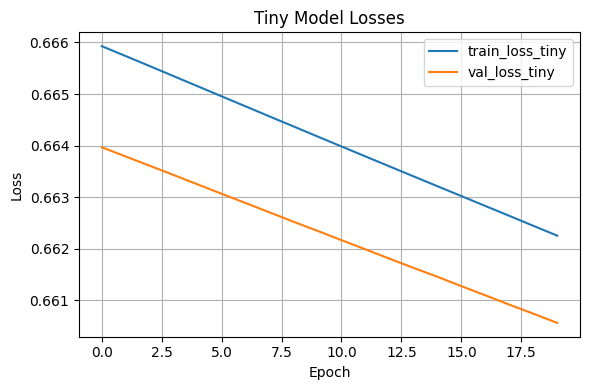

In [35]:
# Plot tiny model losses
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.plot(train_losses_tiny, label='train_loss_tiny')
plt.plot(val_losses_tiny, label='val_loss_tiny')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Tiny Model Losses')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


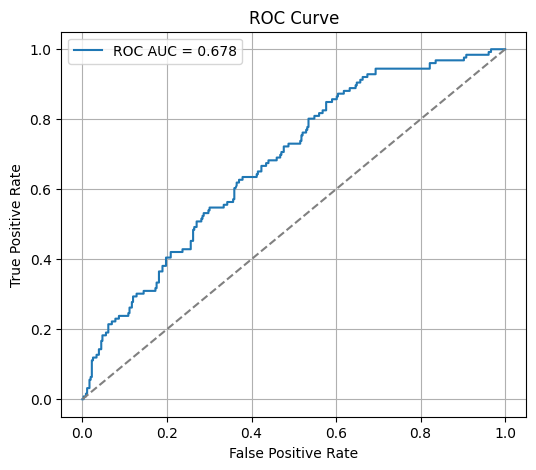

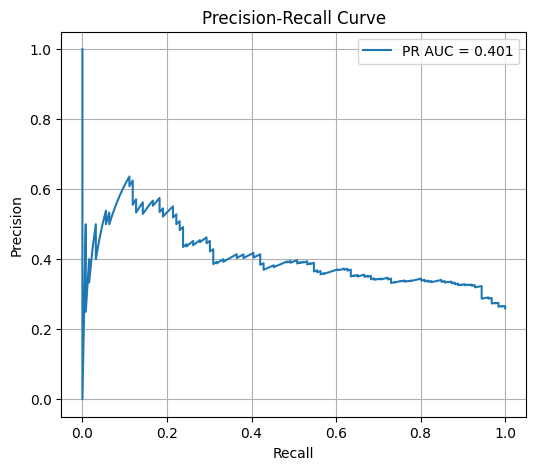

In [36]:
# Collect predictions and true labels from test_loader
tiny.eval()
y_true = []
y_scores = []

with torch.no_grad():
    for xm_b, xs_b, yb_b in test_loader:
        xm_b = xm_b.to(device).float()
        xs_b = xs_b.to(device).float()
        yb_b = yb_b.to(device).float()
        cls_logits, reg_out, _ = tiny(xm_b, xs_b)
        if is_classification:
            probs = torch.sigmoid(cls_logits).cpu().numpy().flatten()
            y_scores.extend(probs.tolist())
        else:
            preds = reg_out.cpu().numpy().flatten()
            y_scores.extend(preds.tolist())
        y_true.extend(yb_b.cpu().numpy().flatten().tolist())

y_true = np.array(y_true)
y_scores = np.array(y_scores)

# Now plot ROC and PR curves
from sklearn.metrics import roc_curve, auc, precision_recall_curve

if is_classification:
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
    plt.plot([0,1],[0,1],'--', color='gray')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title('ROC Curve'); plt.legend(); plt.grid(True); plt.show()

    prec, rec, _ = precision_recall_curve(y_true, y_scores)
    pr_auc = auc(rec, prec)
    plt.figure(figsize=(6,5))
    plt.plot(rec, prec, label=f'PR AUC = {pr_auc:.3f}')
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title('Precision-Recall Curve'); plt.legend(); plt.grid(True); plt.show()


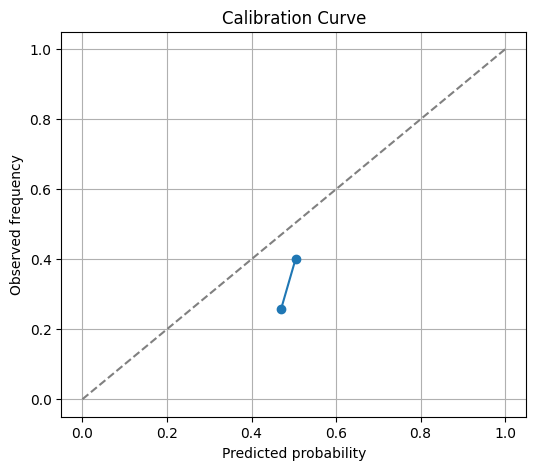

ECE: 0.21070267717862864


In [37]:
# Plot 3 Calibration curve and ECE
from sklearn.calibration import calibration_curve
import numpy as np

prob_true, prob_pred = calibration_curve(y_true, y_scores, n_bins=10)
plt.figure(figsize=(6,5))
plt.plot(prob_pred, prob_true, marker='o', label='Calibration')
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('Predicted probability'); plt.ylabel('Observed frequency'); plt.title('Calibration Curve'); plt.grid(True); plt.show()

# Expected Calibration Error (ECE)
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0,1,n_bins+1)
    ece = 0.0
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if mask.sum() == 0: continue
        acc = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece += (mask.sum()/len(y_prob)) * abs(acc - conf)
    return ece
print("ECE:", expected_calibration_error(np.array(y_true), np.array(y_scores), n_bins=10))


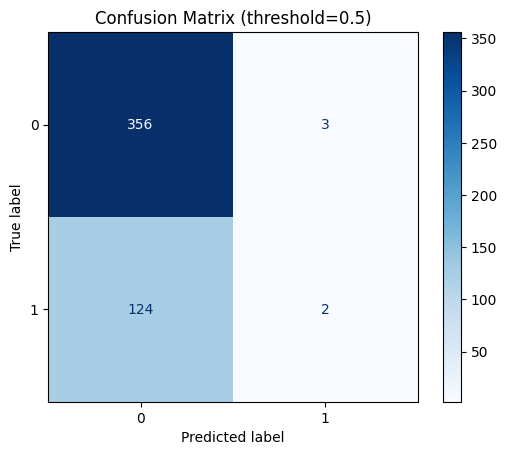

In [38]:
# Plot 4 Confusion matrix at threshold 0.5
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
th = 0.5
pred_labels = (np.array(y_scores) >= th).astype(int)
cm = confusion_matrix(y_true, pred_labels)
disp = ConfusionMatrixDisplay(cm, display_labels=[0,1])
disp.plot(cmap='Blues'); plt.title(f'Confusion Matrix (threshold={th})'); plt.show()


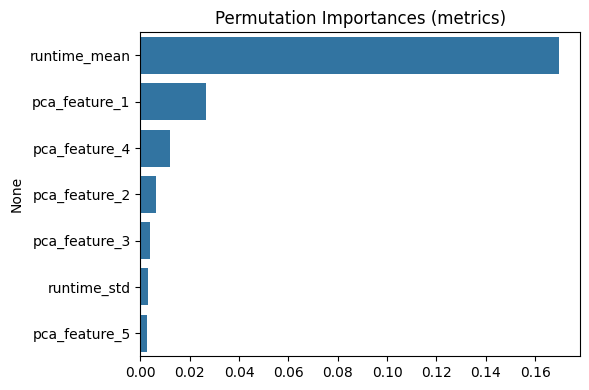

In [39]:
# Feature importance via permutation importance on RandomForest baseline
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.inspection import permutation_importance

if is_classification:
    rf = RandomForestClassifier(n_estimators=200, random_state=42)
else:
    rf = RandomForestRegressor(n_estimators=200, random_state=42)

rf.fit(Xm_train, y_train)
res = permutation_importance(rf, Xm_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
imp = pd.Series(res.importances_mean, index=metrics).sort_values(ascending=False).head(15)

plt.figure(figsize=(6,4))
sns.barplot(x=imp.values, y=imp.index)
plt.title('Permutation Importances (metrics)')
plt.tight_layout()
plt.show()


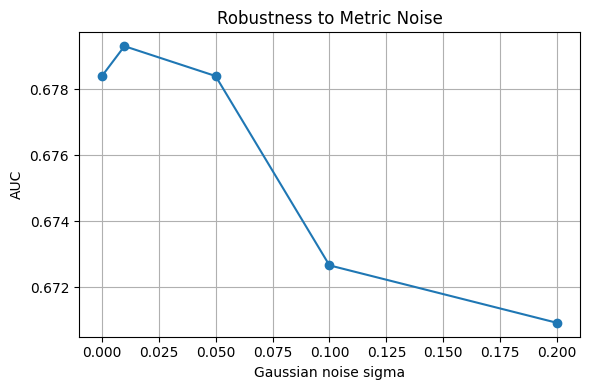

In [40]:
# Plot 7 Robustness test: performance vs Gaussian noise level on metrics
import numpy as np
from sklearn.metrics import roc_auc_score, mean_squared_error

noise_levels = [0.0, 0.01, 0.05, 0.1, 0.2]
scores = []
for sigma in noise_levels:
    Xm_noisy = Xm_test + np.random.normal(0, sigma, size=Xm_test.shape)
    # Use small_model for prediction (or the model you evaluate)
    tiny.eval()
    with torch.no_grad():
        inp_metrics = torch.from_numpy(Xm_noisy).float().to(device)
        inp_seq = torch.from_numpy(Xs_test).float().to(device)
        cls_logits, _, _ = tiny(inp_metrics, inp_seq)
        probs = torch.sigmoid(cls_logits).cpu().numpy().flatten() if is_classification else cls_logits.cpu().numpy().flatten()
    if is_classification:
        scores.append(roc_auc_score(y_test, probs))
    else:
        scores.append(mean_squared_error(y_test, probs))
plt.figure(figsize=(6,4))
plt.plot(noise_levels, scores, marker='o')
plt.xlabel('Gaussian noise sigma'); plt.ylabel('AUC' if is_classification else 'MSE'); plt.title('Robustness to Metric Noise'); plt.grid(True); plt.tight_layout(); plt.show()


In [41]:
# Paste-ready cell: Train RandomForest on metric features, compute performance metrics,
# calibration (ECE), confusion matrix, and permutation importances (top 15).
# Assumes Xm_train, Xm_test, y_train, y_test (numpy arrays) exist from prior pipeline.
# If they do not, the cell will try to fall back to X_metrics / y and create a train/test split.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score,
                             recall_score, f1_score, confusion_matrix, roc_curve,
                             precision_recall_curve)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.calibration import calibration_curve

# --- Helper: Expected Calibration Error
def expected_calibration_error(y_true, y_prob, n_bins=10):
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece += (mask.sum() / len(y_prob)) * abs(acc - conf)
    return ece

# --- Locate or create train/test arrays
try:
    Xm_train  # check existence
    Xm_test
    y_train
    y_test
    print("Using existing Xm_train/Xm_test/y_train/y_test from workspace.")
except Exception:
    # Fallback: try X_metrics and y
    if 'X_metrics' in globals() and 'y' in globals():
        print("Xm_train not found. Creating train/test split from X_metrics and y.")
        Xm_train, Xm_test, y_train, y_test = train_test_split(
            X_metrics, y, test_size=0.2, stratify=y if (len(np.unique(y))==2) else None, random_state=42)
    else:
        raise RuntimeError("Could not find Xm_train/Xm_test/y_train/y_test or X_metrics/y in the workspace. Please run the preprocessing cell first.")

# Ensure shapes and types
Xm_train = np.asarray(Xm_train, dtype=np.float32)
Xm_test  = np.asarray(Xm_test, dtype=np.float32)
y_train  = np.asarray(y_train).reshape(-1)
y_test   = np.asarray(y_test).reshape(-1)

# If labels are floats in [0,1] but not binary, binarize at 0.5 for classification metrics
is_binary_label = (len(np.unique(y_train)) == 2)
if not is_binary_label:
    print("Warning: labels appear non-binary. Converting to binary by threshold 0.5 for classification metrics.")
    y_train = (y_train >= 0.5).astype(int)
    y_test  = (y_test  >= 0.5).astype(int)

# --- Train RandomForest classifier
rf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
rf.fit(Xm_train, y_train)

# --- Predictions and probabilities
probs_test = rf.predict_proba(Xm_test)[:, 1]
preds_test = (probs_test >= 0.5).astype(int)

# --- Performance metrics
roc_auc = roc_auc_score(y_test, probs_test)
pr_auc  = average_precision_score(y_test, probs_test)
precision = precision_score(y_test, preds_test, zero_division=0)
recall = recall_score(y_test, preds_test, zero_division=0)
f1 = f1_score(y_test, preds_test, zero_division=0)
cm = confusion_matrix(y_test, preds_test)
ece = expected_calibration_error(y_test, probs_test, n_bins=10)

print(f"RandomForest performance on metric features:")
print(f"  ROC AUC : {roc_auc:.6f}")
print(f"  PR AUC  : {pr_auc:.6f}")
print(f"  Precision (0.5) : {precision:.6f}")
print(f"  Recall    (0.5) : {recall:.6f}")
print(f"  F1-score  (0.5) : {f1:.6f}")
print(f"  ECE (10 bins)   : {ece:.6f}")
print("  Confusion matrix (rows=true, cols=pred):")
print(cm)

Using existing Xm_train/Xm_test/y_train/y_test from workspace.
RandomForest performance on metric features:
  ROC AUC : 0.912079
  PR AUC  : 0.823408
  Precision (0.5) : 0.752294
  Recall    (0.5) : 0.650794
  F1-score  (0.5) : 0.697872
  ECE (10 bins)   : 0.035183
  Confusion matrix (rows=true, cols=pred):
[[332  27]
 [ 44  82]]
